# Random Forest Algorithm
Random Forest is an ensemble learning method used for classification and regression tasks. It operates by constructing multiple decision trees during training and outputting the mode of the classes (classification) or mean prediction (regression) of the individual trees.

### Core Concepts:
- Ensemble Learning: Combines multiple models to improve performance.
- Multiple Decision Trees: Each tree is built using a random subset of the data and features.
- Dual Approach: Suitable for both classification and regression tasks.
- Majority Voting/ Averaging: For classification, the final output is determined by majority voting among trees; for regression, it is the average of predictions.

##### If Decision is already there, why Random Forest?
- Reduces Overfitting: By averaging multiple trees, it reduces the risk of overfitting compared to a single decision tree.
- Improved Accuracy: Generally provides better accuracy and robustness.
- Generalization: Better generalization to unseen data.
- Handles High Dimensional Data: Effective in handling datasets with a large number of features.
- Training Data: In decision tree, small changes in data can lead to different trees. Random Forest mitigates this by averaging multiple trees.
- Stable Predictions: More stable and reliable predictions due to the ensemble approach.

##### Why Ensemble Learning?
- Combines multiple models to improve overall performance by diversifying predictions.
- Reduces the risk of overfitting by averaging out errors from individual models.
- Reduces variance and bias.

The `Random` aspect in Random Forest refers to the random selection of data samples and features used to build each decision tree, enhancing diversity among the trees and improving the overall model's performance.

## Decision Tree
A decision tree is a supervised learning algorithm used for both classification and regression tasks. It works by recursively splitting the data into subsets based on feature values, creating a tree-like structure where each internal node represents a feature, each branch represents a decision rule, and each leaf node represents an outcome or class label.

```graphviz
    Root Node -> Internal Nodes -> Branches -> Leaf Nodes
```

### The Splitting Process:
1. Evaluate all possible splits for each feature.
2. Measure the quality of each split using metrics like Gini impurity, Information Gain, or Mean Squared Error.
3. Choose the split that results in the best separation of classes (for classification) or minimizes error (for regression).
4. Repeat the process recursively for each subset until a stopping criterion is met (e.g., maximum depth, minimum samples per leaf).

### Limitations of Decision Trees:
- Overfitting: Prone to overfitting, especially with deep trees.
- Instability: Small changes in data can lead to different tree structures.
- Learning Bias: Can be biased towards features with more levels.
- High Variance: Sensitive to noise in the data.

Bias-variance tradeoff: Decision trees often have low bias but high variance, meaning they can fit the training data well but may not generalize effectively to unseen data.

## Randomness
Randomness refers to the introduction of variability or unpredictability in a process or system. In the context of machine learning, randomness is often used to enhance model performance, improve generalization, and reduce overfitting. For example, in Random Forests, randomness is introduced by selecting random subsets of data and features to build each decision tree, leading to a diverse ensemble of models that collectively provide more robust predictions.
### Sources of Randomness in Random Forests:
#### Bootstrap Sampling
Each decision tree is trained on a random subset of the training data, selected with replacement. This means that some samples may be included multiple times, while others may be excluded entirely. This technique is known as bootstrap sampling.\
How it works:
- Each sample mathes the original dataset size.
- Some rows may be repeated, while others may be left out (out-of-bag samples).
- Every tree gets a unique training set.

Approximately 63.2% of the original samples are included in each bootstrap sample, while the remaining 36.8% are out-of-bag samples used for validation. An OOB sample is a data point that is not included in the bootstrap sample for a particular tree. OBB samples act as a validation set to estimate the model's performance without needing a separate validation dataset.

Example: Let a dataset have 5 samples: ${A, B, C, D, E}$. A bootstrap sample could be ${A, C, C, D, E}$. There could be limitless combinations. OOB samples for this tree would be ${B}$.
#### Random Feature Selection
When splitting nodes in each decision tree, a random subset of features is considered rather than evaluating all features. This randomness helps to create diverse trees and reduces correlation among them.\
How it works:
- At each split, randomly select a subset of features.
- Choose the best split from this subset.
- This randomness increases diversity among trees.

Feature selection can prevent dominant features from overshadowing others, leading to a more balanced model. Forces diversity among trees, which is crucial for the ensemble's effectiveness.

Example: Let's say we have 4 features: ${F1, F2, F3, F4}$. For a particular split, first tree might randomly select ${F1, F3}$, while the second tree might select ${F2, F4}$.

# Bagging
Bagging, or Bootstrap Aggregating, is an ensemble learning technique used to improve the stability and accuracy of machine learning algorithms. It involves creating multiple subsets of the original dataset through bootstrap sampling (sampling with replacement) and training a separate model on each subset. The final prediction is made by aggregating the predictions from all models, typically through majority voting for classification tasks or averaging for regression tasks.
$$\text{Bagging} = \text{Bootstrap Sampling} + \text{Aggregation}$$

### Hperparameters of Random Forest
- Number of Trees (`n_estimators`): The number of decision trees to be created in the forest. If too low, the model may underfit; if too high, it may lead to increased computational cost without significant performance gain. For most applications, values between 100 and 500 are common starting points.
- Maximum Depth (`max_depth`): The maximum depth of each decision tree. Limiting the depth can help prevent overfitting. A common approach is to start with a depth of 10-20 and adjust based on performance.
- Minimum Samples Split (`min_samples_split`): The minimum number of samples required to split an internal node. Higher values can prevent the model from learning overly specific patterns, thus reducing overfitting. A typical starting point is 2-10.
- Features Per Split (`max_features`): The number of features to consider when looking for the best split. Common strategies include using the square root or log2 of the total number of features for classification tasks and one-third for regression tasks.

To find the optimal hyperparameters, techniques such as Grid Search or Random Search combined with cross-validation can be employed. These methods systematically explore different combinations of hyperparameters to identify the configuration that yields the best performance on validation data.  

In [21]:
# Random Forest Algorithm on Classsification
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

data = load_breast_cancer()

X = data.data
y = data.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

rf_baseline = RandomForestClassifier(
    n_estimators=10,
    random_state=42
)

rf_baseline.fit(X_train, y_train)

RandomForestClassifier(n_estimators=10, random_state=42)

Accuracy: 0.9510
              precision    recall  f1-score   support

   malignant       0.93      0.94      0.93        53
      benign       0.97      0.96      0.96        90

    accuracy                           0.95       143
   macro avg       0.95      0.95      0.95       143
weighted avg       0.95      0.95      0.95       143



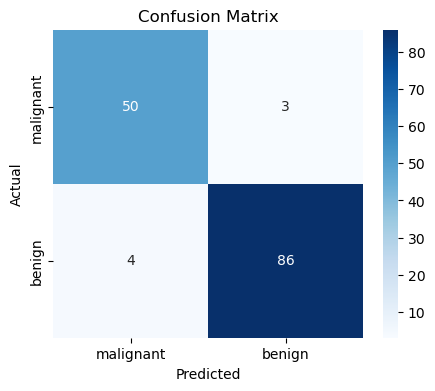

In [4]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

y_pred = rf_baseline.predict(X_test)
print(f'Accuracy: {accuracy_score(y_test, y_pred):.4f}')
print(classification_report(y_test, y_pred, target_names=data.target_names))

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=data.target_names,
            yticklabels=data.target_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [22]:
# Importance Features
import pandas as pd

importances = pd.Series(
    rf_baseline.feature_importances_,
    index=data.feature_names
).sort_values(ascending=False)
importances.head(10)

worst concave points    0.219597
mean concave points     0.098235
mean perimeter          0.090414
worst area              0.090201
worst radius            0.085263
mean radius             0.076653
area error              0.059317
radius error            0.051290
worst compactness       0.044146
worst texture           0.030739
dtype: float64

In [7]:
#Key Hyperparameters
from sklearn.model_selection import GridSearchCV

param_grid={
    "n_estimators": [100,150,175,200],
    "max_depth": [None, 5, 10, 15],
    "min_samples_split": [2,3,5],
    "max_features": ["sqrt", "log2"]
}

grid_rf = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=5,           # CV for cross-validation, means 5 different validation sets
    scoring="f1",   # model evaluation metric
    n_jobs=-1    # use all CPU cores to run the process faster
)

grid_rf.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [None, 5, 10, 15],
                         'max_features': ['sqrt', 'log2'],
                         'min_samples_split': [2, 3, 5],
                         'n_estimators': [100, 150, 175, 200]},
             scoring='f1')

In [8]:
print("Best Hyperparameters:", grid_rf.best_params_)

Best Hyperparameters: {'max_depth': 5, 'max_features': 'log2', 'min_samples_split': 3, 'n_estimators': 100}


Accuracy after Hyperparameter Tuning: 0.9580
              precision    recall  f1-score   support

   malignant       0.96      0.92      0.94        53
      benign       0.96      0.98      0.97        90

    accuracy                           0.96       143
   macro avg       0.96      0.95      0.95       143
weighted avg       0.96      0.96      0.96       143



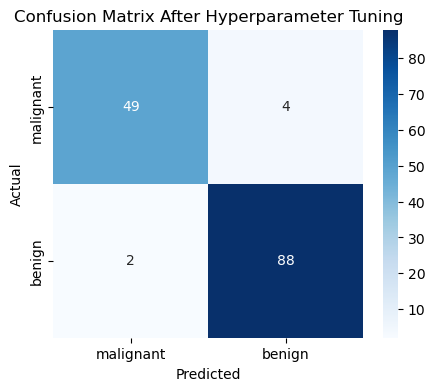

In [ ]:
best_rf = grid_rf.best_estimator_
y_pred_best = best_rf.predict(X_test)

print(f'Accuracy after Hyperparameter Tuning: {accuracy_score(y_test, y_pred_best):.4f}')
print(classification_report(y_test, y_pred_best, target_names=data.target_names))

cm_best = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(5,4))
sns.heatmap(cm_best, annot=True, fmt="d", cmap="Blues",
            xticklabels=data.target_names,
            yticklabels=data.target_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix After Hyperparameter Tuning")
plt.show()

In [23]:
# Random Forest Algorithm on Regression
from sklearn.datasets import fetch_california_housing
from sklearn.ensemble import RandomForestRegressor

data_reg = fetch_california_housing()
X = data_reg.data
y = data_reg.target

X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X, y, test_size=0.2, random_state=42
)

rf_reg = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)
rf_reg.fit(X_train_reg, y_train_reg)

RandomForestRegressor(n_estimators=300, n_jobs=-1, random_state=42)

In [24]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

y_pred_reg = rf_reg.predict(X_test_reg)

print(f'Mean Squared Error: {mean_squared_error(y_test_reg, y_pred_reg):.4f}')
print(f'Mean Absolute Error: {mean_absolute_error(y_test_reg, y_pred_reg):.4f}')
print(f"RMSE: {np.sqrt(mean_squared_error(y_test_reg, y_pred_reg)):.4f}")
print(f'R^2 Score: {r2_score(y_test_reg, y_pred_reg):.4f}')



Mean Squared Error: 0.2534
Mean Absolute Error: 0.3266
RMSE: 0.5034
R^2 Score: 0.8066


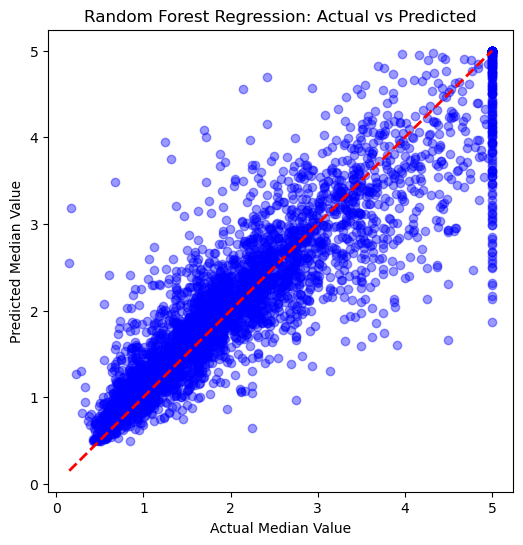

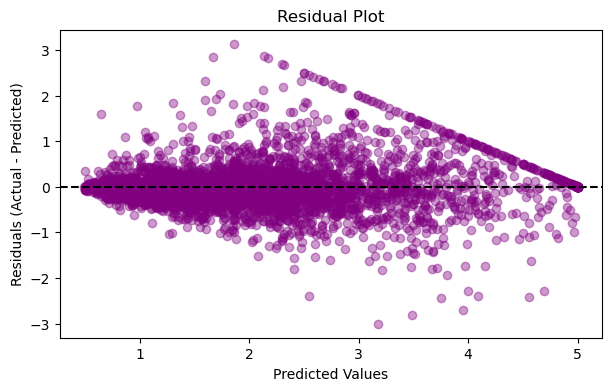

In [ ]:
plt.figure(figsize=(6,6))
plt.scatter(y_test_reg, y_pred_reg, alpha=0.4, color='blue')
plt.plot([y_test_reg.min(), y_test_reg.max()], [y_test_reg.min(), y_test_reg.max()], 'r--', lw=2) # Perfect prediction line
plt.xlabel("Actual Median Value")
plt.ylabel("Predicted Median Value")
plt.title("Random Forest Regression: Actual vs Predicted")
plt.show()

residuals = y_test_reg - y_pred_reg
plt.figure(figsize=(7,4))
plt.scatter(y_pred_reg, residuals, alpha=0.4, color='purple')
plt.axhline(0, color='black', linestyle='--')
plt.xlabel("Predicted Values")
plt.ylabel("Residuals (Actual - Predicted)")
plt.title("Residual Plot")
plt.show()